In [282]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error ,r2_score ,mean_absolute_error
import os

In [283]:
train = pd.read_csv(os.path.join("..", "house price data", "train.csv"))
test = pd.read_csv(os.path.join("..", "house price data", "test.csv"))


In [284]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [285]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [286]:
train.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [287]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


## test

In [288]:
test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [289]:
train.isna().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [290]:
train.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [291]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


## Analysis

In [292]:
train = train[[
    "Id",
    "Neighborhood",
    "Foundation",
    "YearBuilt",
    "OverallQual",
    "OverallCond",
    "YrSold",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "KitchenQual",
    "GarageArea",
    "LotArea",
    "MasVnrArea",
    "BsmtFinSF1",
    "BsmtUnfSF",
    "1stFlrSF",
    "2ndFlrSF",
    'FullBath',
    'TotRmsAbvGrd',
    'GarageYrBlt',
    'YearRemodAdd',
    'Fireplaces',
    "HalfBath"  ,  
    "SalePrice"
]]


In [293]:
test = test[[
    "Id",
    "Neighborhood",
    "Foundation",
    "YearBuilt",
    "OverallQual",
    "OverallCond",
    "YrSold",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "KitchenQual",
    "GarageArea",
    "LotArea",
    "MasVnrArea",
    "BsmtFinSF1",
    "BsmtUnfSF",
    "1stFlrSF",
    "PoolArea",
    "2ndFlrSF",
    'FullBath',
    'TotRmsAbvGrd',
    'GarageYrBlt',
    'YearRemodAdd',
    'Fireplaces',
    "HalfBath"
    ]]


In [294]:
train.head()

,Id,Neighborhood,Foundation,YearBuilt,OverallQual,OverallCond,YrSold,GrLivArea,GarageCars,TotalBsmtSF,...,BsmtUnfSF,1stFlrSF,2ndFlrSF,FullBath,TotRmsAbvGrd,GarageYrBlt,YearRemodAdd,Fireplaces,HalfBath,SalePrice
0,1,CollgCr,PConc,2003,7,5,2008,1710,2,856,...,150,856,854,2,8,2003.0,2003,0,1,208500
1,2,Veenker,CBlock,1976,6,8,2007,1262,2,1262,...,284,1262,0,2,6,1976.0,1976,1,0,181500
2,3,CollgCr,PConc,2001,7,5,2008,1786,2,920,...,434,920,866,2,6,2001.0,2002,1,1,223500
3,4,Crawfor,BrkTil,1915,7,5,2006,1717,3,756,...,540,961,756,1,7,1998.0,1970,1,0,140000
4,5,NoRidge,PConc,2000,8,5,2008,2198,3,1145,...,490,1145,1053,2,9,2000.0,2000,1,1,250000


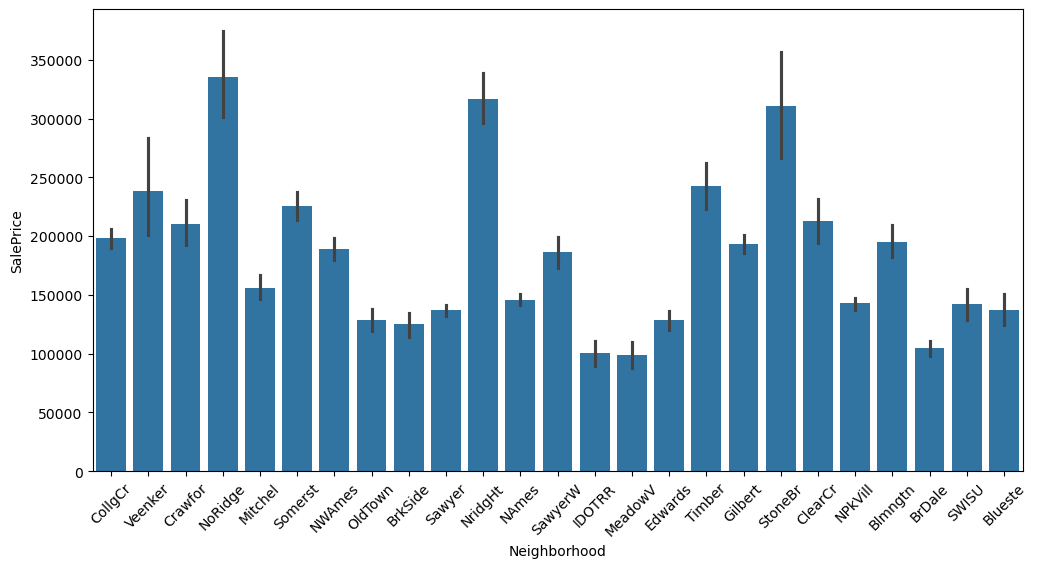

In [295]:
plt.figure(figsize=(12, 6))
sns.barplot(x="Neighborhood", y="SalePrice", data=train)
plt.xticks(rotation=45)
plt.show()

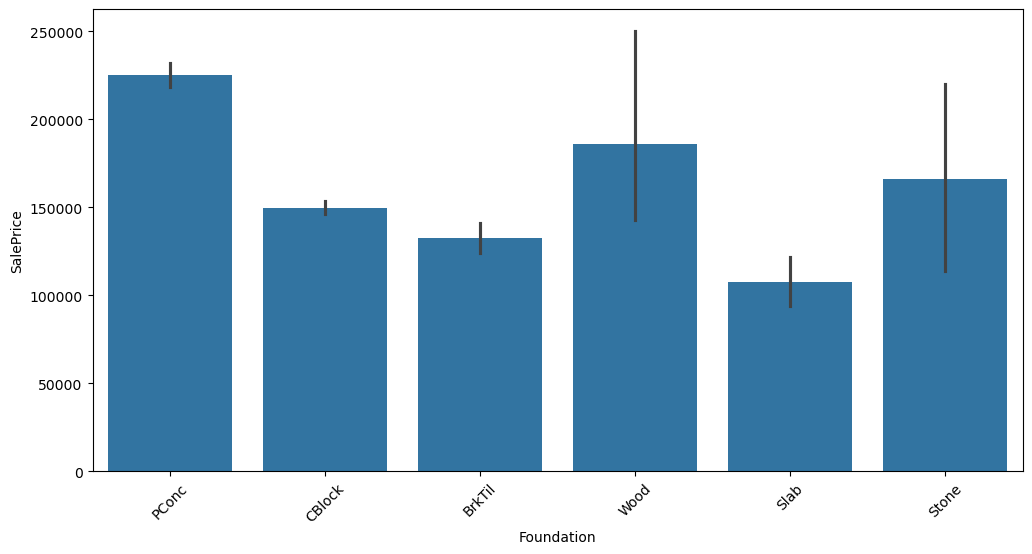

In [296]:
plt.figure(figsize=(12, 6))
sns.barplot(x="Foundation", y="SalePrice", data=train)
plt.xticks(rotation=45)
plt.show()

In [297]:
FoundationNeighborhoodPrice = (
    train.groupby(["Foundation", "Neighborhood"])["SalePrice"]
    .sum()
    .reset_index()
)

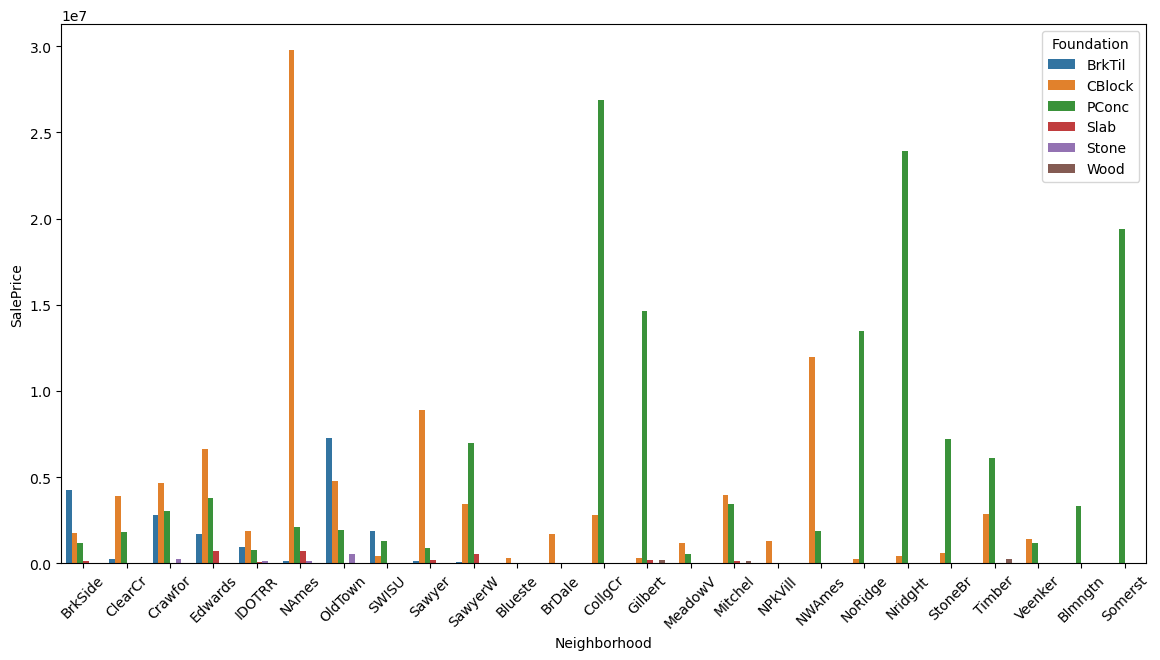

In [298]:
plt.figure(figsize=(14, 7))

sns.barplot(
    data=FoundationNeighborhoodPrice,
    x="Neighborhood",
    y="SalePrice",
    hue="Foundation"
)

plt.xticks(rotation=45)
plt.show()

## ML

In [299]:
train['TotalSF'] = train['TotalBsmtSF'] + train['1stFlrSF'] + train['2ndFlrSF']
test['TotalSF'] = test['TotalBsmtSF'] + test['1stFlrSF'] + test['2ndFlrSF']
train["HouseAge"] = train["YrSold"] - train["YearBuilt"]
test["HouseAge"] = test["YrSold"] - test["YearBuilt"]
train["TotalBath"] = train["FullBath"] + train["HalfBath"] * 0.5
test["TotalBath"] = test["FullBath"] + test["HalfBath"] * 0.5


In [300]:
feature = [
    "Neighborhood",
    "Foundation",
    "OverallQual",
    "OverallCond",
    "TotalBath",
    "HouseAge",
    "GrLivArea",
    "GarageCars",
    "TotalSF",
    "KitchenQual",
    "GarageArea",
    "LotArea",
    "MasVnrArea",
    "BsmtFinSF1",
    "BsmtUnfSF",
    'TotRmsAbvGrd',
    'GarageYrBlt',
    'YearRemodAdd',
    'Fireplaces']

In [301]:
y = train["SalePrice"]
x = train.drop(["SalePrice", 'Id'], axis=1)
x = pd.get_dummies(train[feature]).fillna(0)

xTrain,xTest,yTrain,yTest = train_test_split(x,y,random_state=42, test_size= 0.15 )

In [302]:
linear = LinearRegression()
linear.fit(xTrain,yTrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [303]:
pred = linear.predict(xTest)

print("R²:", r2_score(yTest, pred))
print("MSE:", mean_squared_error(yTest, pred))

R²: 0.8630537747519402
MSE: 1111807072.2155592


In [304]:
t = DecisionTreeRegressor(
    max_depth=30,
    min_samples_split=35,
    min_samples_leaf=1,
    splitter='best',
    random_state=42
)
t.fit(xTrain,yTrain)


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",35
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_le

In [305]:
predtree = t.predict(xTest)

print("R²:", r2_score(yTest, predtree))
print("MSE:", mean_squared_error(yTest, predtree))

R²: 0.8290813990615801
MSE: 1387614072.2558284


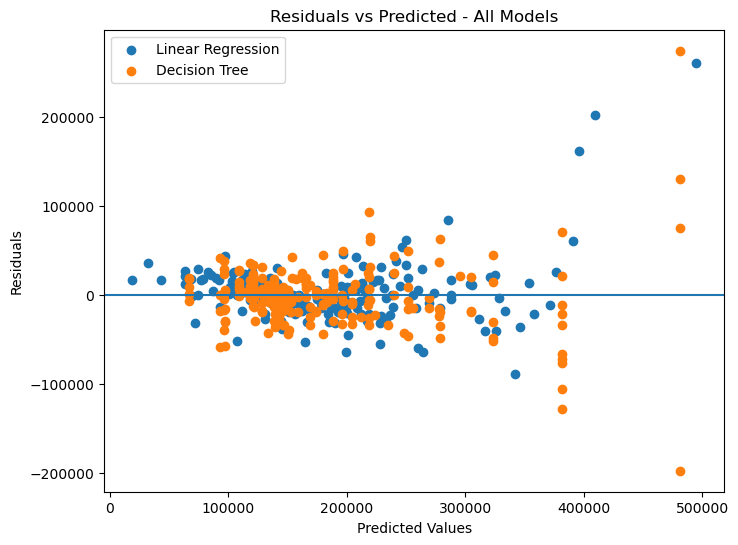

In [306]:
model = {
    "Linear Regression": linear,
    "Decision Tree": t
}
plt.figure(figsize=(8, 6))

for name, mode in model.items():
    pred = mode.predict(xTest)
    residuals = yTest - pred

    plt.scatter(pred, residuals, label=name)

plt.axhline(0)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted - All Models")
plt.legend()

plt.show()

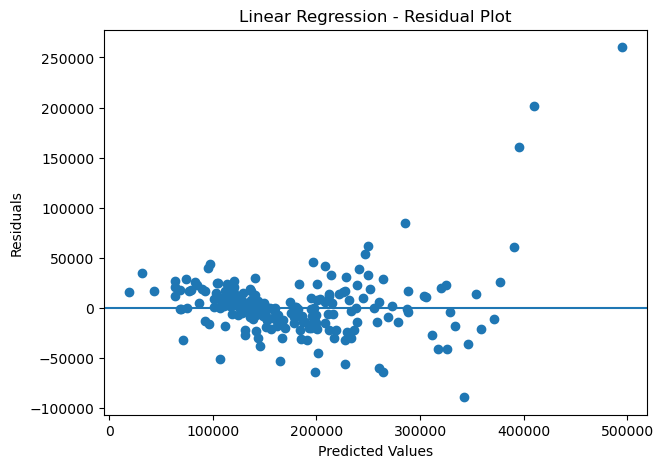

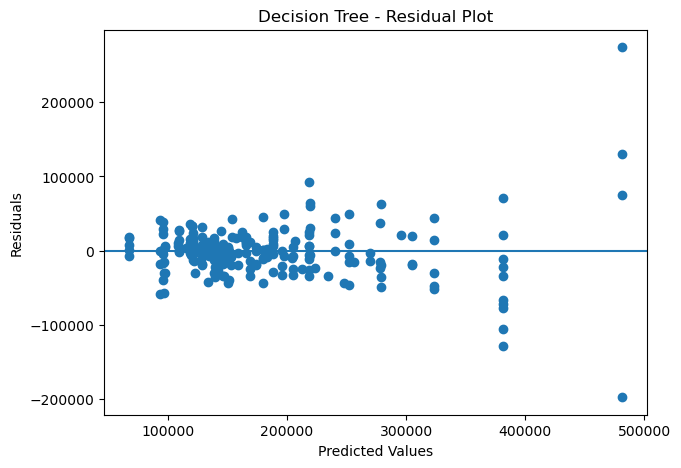

In [307]:
for name, mode in model.items():
    pred = mode.predict(xTest)
    residuals = yTest - pred

    plt.figure(figsize=(7, 5))
    plt.scatter(pred, residuals)
    plt.axhline(0)

    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.title(f"{name} - Residual Plot")

    plt.show()

## fixing the funnel shape 


In [308]:
yTrain_log = np.log1p(yTrain)
yTest_log = np.log1p(yTest)

In [309]:
treelog = DecisionTreeRegressor(
    max_depth=30,
    min_samples_split=35,
    min_samples_leaf=1,
    splitter='best',
    random_state=42
)
treelog.fit(xTrain,yTrain_log)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",35
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_le

In [310]:
linearlog = LinearRegression()
linearlog.fit(xTrain,yTrain_log)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [311]:
models = {
    "Linear Regression": linearlog,
    "Decision Tree": treelog
}

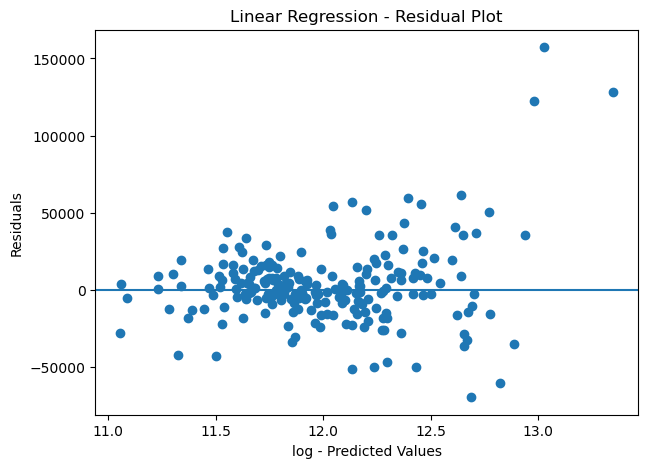

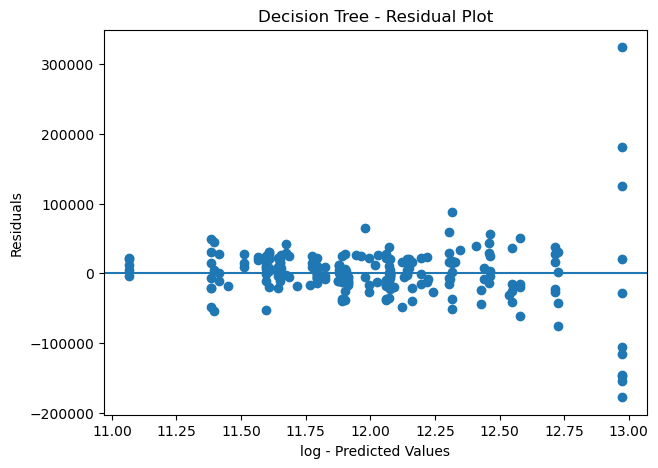

In [312]:
for name, model in models.items():
    pred_log = model.predict(xTest)
    pred = np.expm1(pred_log)
    residuals = yTest - pred

    plt.figure(figsize=(7, 5))
    plt.scatter(pred_log, residuals)
    plt.axhline(0)

    plt.xlabel("log - Predicted Values")
    plt.ylabel("Residuals")
    plt.title(f"{name} - Residual Plot")

    plt.show()

[Linear Regression] R²: 0.8630537747519402
[Linear Regression] RMSE: 33343.77111569055
[Linear Regression] MAE: 18941.255531277384


AttributeError: module 'sklearn.tree' has no attribute 'predict'

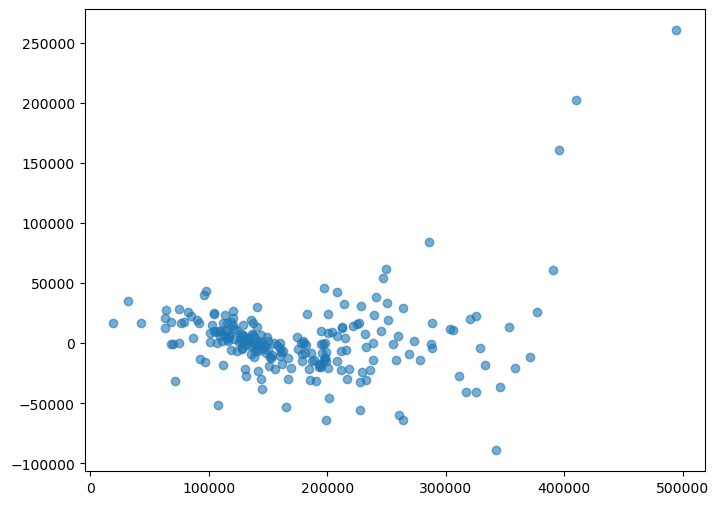

In [ ]:
models = {
    "Linear Regression": linear,
    "Decision Tree": t,
    "Log Linear Regression": linearlog,
    "Log Decision Tree": treelog 
}

plt.figure(figsize=(8, 6))

for name, model in models.items():

    pred = model.predict(xTest)

    # Convert log-model predictions back to original price scale
    if name.startswith("Log"):
        pred = np.expm1(pred)

    residuals = yTest - pred

    plt.scatter(pred, residuals, label=name, alpha=0.6)
    print(f"[{name}] R²: {r2_score(yTest, pred)}")
    print(f"[{name}] RMSE: {np.sqrt(mean_squared_error(yTest, pred))}")
    print(f"[{name}] MAE: {mean_absolute_error(yTest, pred)}")

plt.axhline(0)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted - All Models")
plt.legend()

plt.show()

## Model Comparison After Log Transformation

| Model | R² | RMSE | MAE |
|---|---:|---:|---:|
| Linear Regression | 0.862 | 33,461 | 19,109 |
| Decision Tree | 0.849 | 34,978 | 23,995 |
| **Log Linear Regression** | **0.915** | **26,289** | **16,822** |
| Log Decision Tree | 0.758 | 44,329 | 23,742 |

### Conclusion

**Log Linear Regression performs best**, improving R² from **0.862 → 0.915** and reducing RMSE by about **21%**.

The log transformation helped Linear Regression handle the increasing variance in house prices, while it **hurt the Decision Tree**.

**Best model: Log Linear Regression.**

In [ ]:
test_features = pd.get_dummies(test[feature]).fillna(0)
submission_predictions = linearlog.predict(test_features)
pred = np.expm1(submission_predictions)
submission_df = pd.DataFrame({'Id': test['Id'], 'SalePrice': pred})
submission_df.to_csv('submission.csv', index=False)

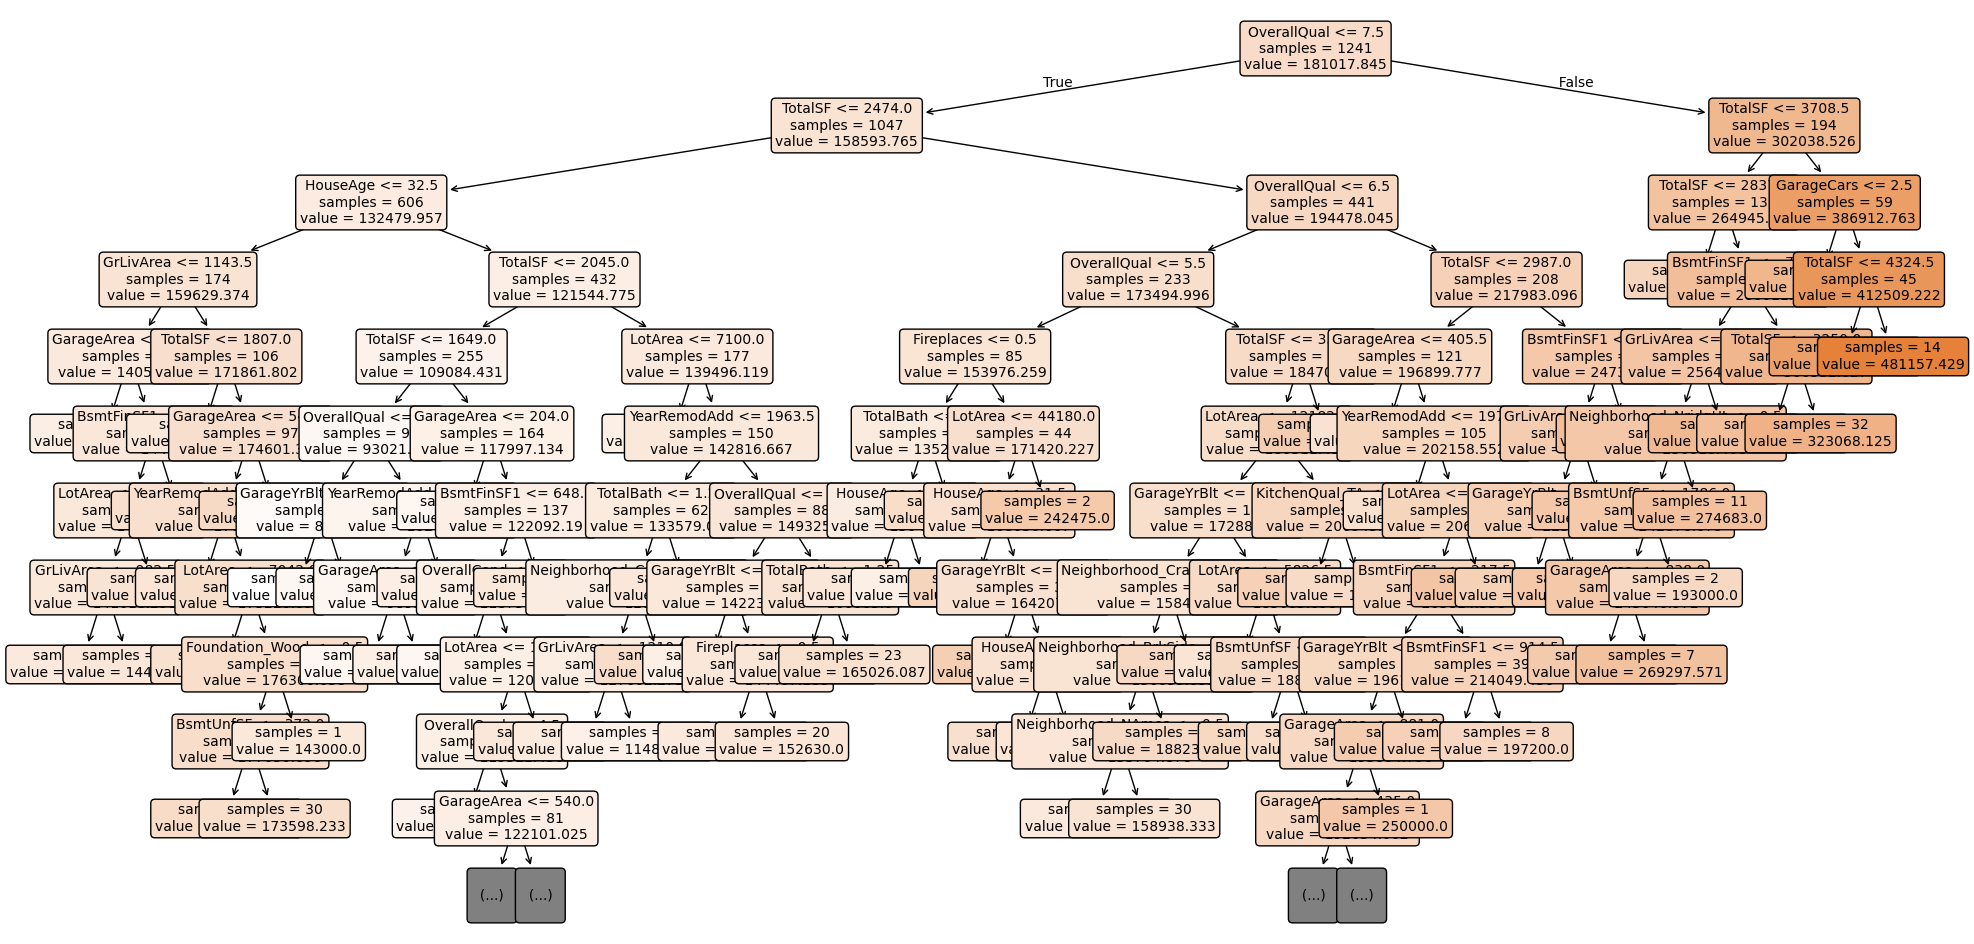

In [319]:
from sklearn import tree

plt.figure(figsize=(24, 12))

tree.plot_tree(
    t,
    feature_names=xTrain.columns,
    filled=True,
    rounded=True,
    max_depth=10,
    fontsize=10,
    impurity=False
)

plt.show()